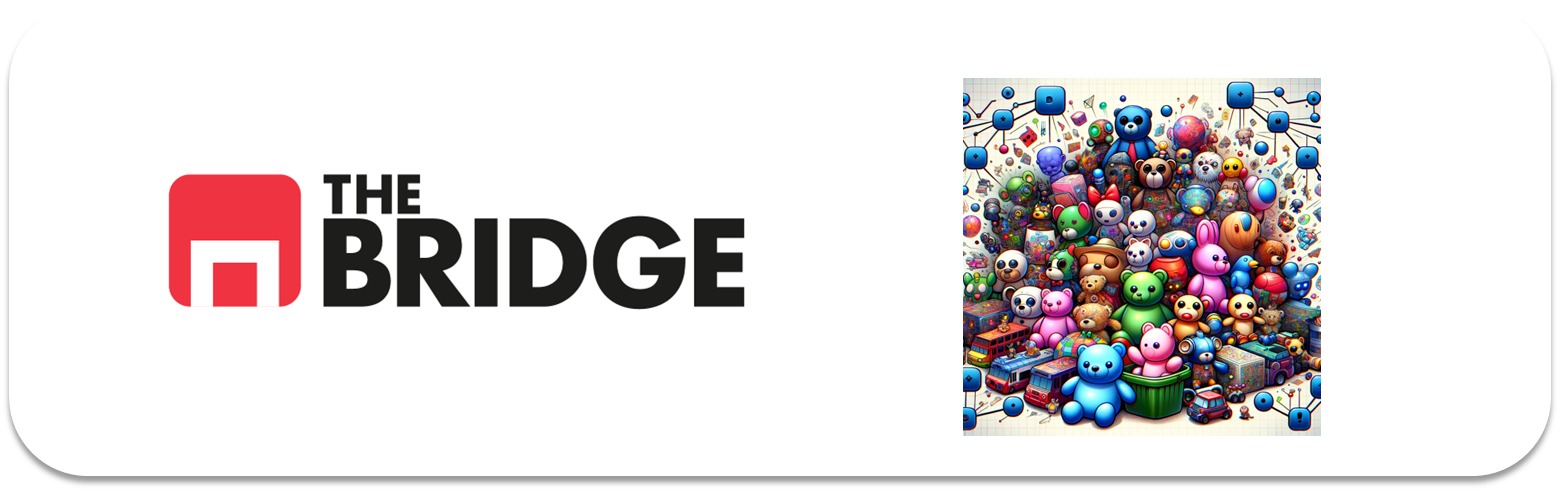

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no
supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook
en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de
imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que
puntúe adecuadamente.
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el
esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará
en el repo del curso.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

np.random.seed(42)


## **#1**

Vamos a trabajar con un dataset también entre los "clásicos" (aunque a veces menos
conocido) que es el de rostros Olivetti. Este dataset contiene 400 imágenes de rostros en
escala de grises con un tamaño de 64 × 64 píxeles.

Como en otros datasets de imágenes, estás están "aplanadas" de forma que cada pixel es una
feature y por cada imagen hay $64\times 64 = 4096$ features.

Se fotografiaron 40 personas diferentes (10 veces cada una) y esas fotografías se recogen en
el dataset.

La tarea habitual es entrenar un modelo que pueda predecir qué persona está representada en
cada imagen, pero nosotros lo vamos a hacer de forma no supervisada.

### #1.1

Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`.
Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave
"DESCR".

In [2]:
# Truco para entornos con problemas de verificación SSL al descargar el dataset.
# https://github.com/scikit-learn/scikit-learn/issues/10201

# import os, ssl
# if (not os.environ.get('PYTHONHTTPSVERIFY', '') and
#     getattr(ssl, '_create_unverified_context', None)):
#     ssl._create_default_https_context = ssl._create_unverified_context


In [3]:
caras_bunch = fetch_olivetti_faces()
caras_bunch


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\HP\scikit_learn_data


{'data': array([[0.30991736, 0.3677686 , 0.41735536, ..., 0.15289256, 0.16115703,
         0.1570248 ],
        [0.45454547, 0.47107437, 0.5123967 , ..., 0.15289256, 0.15289256,
         0.15289256],
        [0.3181818 , 0.40082645, 0.49173555, ..., 0.14049587, 0.14876033,
         0.15289256],
        ...,
        [0.5       , 0.53305787, 0.607438  , ..., 0.17768595, 0.14876033,
         0.19008264],
        [0.21487603, 0.21900827, 0.21900827, ..., 0.57438016, 0.59090906,
         0.60330576],
        [0.5165289 , 0.46280992, 0.28099173, ..., 0.35950413, 0.3553719 ,
         0.38429752]], shape=(400, 4096), dtype=float32),
 'images': array([[[0.30991736, 0.3677686 , 0.41735536, ..., 0.37190083,
          0.3305785 , 0.30578512],
         [0.3429752 , 0.40495867, 0.43801653, ..., 0.37190083,
          0.338843  , 0.3140496 ],
         [0.3429752 , 0.41735536, 0.45041323, ..., 0.38016528,
          0.338843  , 0.29752067],
         ...,
         [0.21487603, 0.20661157, 0.2231405 , ...

In [4]:
print(caras_bunch.DESCR)


.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

### #1.2

Muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y
obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el
método `sample` del dataframe o el método que tú quieras)

In [5]:
caras_bunch.target


array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

*El punto clave aquí es que el dataset viene ordenado por persona (target): las 10 fotos
de la persona 0 primero, luego las 10 de la persona 1, etc. -- de ahí que después necesitemos
barajarlo.*

In [6]:
caras_bunch.data.shape[0]


400

In [7]:
nombres_columnas = [f"pixel_{idx}" for idx in range(caras_bunch.data.shape[1])]
df_caras = pd.DataFrame(caras_bunch.data, columns=nombres_columnas)
df_caras


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4086,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.665289,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.136364,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.652893,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.190083,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.400826,0.495868,0.570248,0.632231,0.648760,0.640496,0.661157,0.636364,0.665289,0.698347,...,0.388430,0.396694,0.264463,0.099174,0.181818,0.243802,0.247934,0.161157,0.157025,0.136364
396,0.367769,0.367769,0.351240,0.301653,0.247934,0.247934,0.367769,0.512397,0.574380,0.628099,...,0.380165,0.334711,0.289256,0.285124,0.338843,0.404959,0.458678,0.487603,0.512397,0.549587
397,0.500000,0.533058,0.607438,0.628099,0.657025,0.632231,0.657025,0.669421,0.673554,0.702479,...,0.194215,0.148760,0.152893,0.161157,0.161157,0.173554,0.157025,0.177686,0.148760,0.190083
398,0.214876,0.219008,0.219008,0.223140,0.210744,0.202479,0.276859,0.400826,0.487603,0.549587,...,0.446281,0.392562,0.367769,0.409091,0.479339,0.524793,0.545455,0.574380,0.590909,0.603306


In [8]:
df_caras["persona"] = caras_bunch.target


*Como cabía esperar, la columna `persona` sigue perfectamente ordenada :-)*

In [9]:
df_caras_original = df_caras.copy()  # nos guardamos una copia sin barajar, por si acaso


In [10]:
df_caras_original.sample(frac=1, random_state=42)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095,persona
209,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909,20
280,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744,28
33,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975,3
210,0.136364,0.140496,0.185950,0.280992,0.318182,0.363636,0.409091,0.417355,0.438017,0.454545,...,0.169421,0.206612,0.276859,0.355372,0.685950,0.661157,0.280992,0.371901,0.276859,21
93,0.652893,0.644628,0.652893,0.706612,0.714876,0.719008,0.743802,0.747934,0.747934,0.756198,...,0.074380,0.074380,0.082645,0.082645,0.111570,0.070248,0.086777,0.185950,0.231405,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.194215,0.223140,0.314050,0.500000,0.636364,0.735537,0.797521,0.826446,0.847107,0.847107,...,0.206612,0.181818,0.165289,0.123967,0.123967,0.128099,0.136364,0.169421,0.165289,7
106,0.260331,0.355372,0.648760,0.822314,0.838843,0.834711,0.830579,0.826446,0.822314,0.814050,...,0.264463,0.185950,0.136364,0.177686,0.132231,0.103306,0.103306,0.107438,0.119835,10
270,0.611570,0.644628,0.657025,0.669421,0.673554,0.710744,0.735537,0.756198,0.760331,0.768595,...,0.152893,0.107438,0.119835,0.132231,0.111570,0.136364,0.177686,0.210744,0.223140,27
348,0.285124,0.293388,0.297521,0.293388,0.219008,0.107438,0.342975,0.508264,0.533058,0.557851,...,0.388430,0.442149,0.475207,0.500000,0.516529,0.520661,0.533058,0.533058,0.537190,34


In [11]:
df_caras = df_caras_original.sample(frac=1, random_state=42).reset_index(drop=True)
df_caras["persona"]


0      20
1      28
2       3
3      21
4       9
       ..
395     7
396    10
397    27
398    34
399    10
Name: persona, Length: 400, dtype: int64

*Y ahora ya no está ordenado.*

### #1.3

Vamos a dividir en train y test pero, OJO, RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO
HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el
clustering con la clasificación (ya que es una práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto
de pruebas (320 registros-40 registros-40 registros). Dado que el conjunto de datos es
bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo
número de imágenes por persona en cada conjunto (estratificando por la columna que contenga
el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien
haz primero un split 360-40 (resto-test) en registros y luego otro split sobre los 360 en
280-80. (train-validation)

In [12]:
df_caras["persona"].value_counts(normalize=True)


persona
20    0.025
28    0.025
3     0.025
21    0.025
9     0.025
8     0.025
32    0.025
26    0.025
12    0.025
0     0.025
36    0.025
5     0.025
7     0.025
13    0.025
4     0.025
27    0.025
37    0.025
23    0.025
38    0.025
1     0.025
39    0.025
11    0.025
22    0.025
10    0.025
19    0.025
34    0.025
15    0.025
14    0.025
2     0.025
18    0.025
17    0.025
33    0.025
29    0.025
25    0.025
35    0.025
24    0.025
6     0.025
30    0.025
31    0.025
16    0.025
Name: proportion, dtype: float64

In [13]:
def split_train_val_test(dataframe, columna_target, n_test=80, n_val=40, semilla=42):
    """Split en dos pasos encadenados (resto/test y luego train/val),
    ambos estratificados por columna_target."""
    resto, test = train_test_split(
        dataframe, test_size=n_test, stratify=dataframe[columna_target], random_state=semilla
    )
    train, val = train_test_split(
        resto, test_size=n_val, stratify=resto[columna_target], random_state=semilla + 1
    )
    return train, val, test


train_set, validation_set, test_set = split_train_val_test(df_caras, "persona", n_test=80, n_val=40)


In [14]:
for nombre_set, subset in [("test", test_set), ("validation", validation_set), ("train", train_set)]:
    print(f"{nombre_set}: {len(subset)} registros")


test: 80 registros
validation: 40 registros
train: 280 registros


### #1.4

Crea los pares X, y para train, validation y test.

In [15]:
conjuntos = {"train": train_set, "valid": validation_set, "test": test_set}

X = {nombre: subset.drop(columns="persona") for nombre, subset in conjuntos.items()}
y = {nombre: subset["persona"] for nombre, subset in conjuntos.items()}

X_train, X_valid, X_test = X["train"], X["valid"], X["test"]
y_train, y_valid, y_test = y["train"], y["valid"], y["test"]

X_train.shape, X_valid.shape, X_test.shape


((280, 4096), (40, 4096), (80, 4096))

Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que
dar la X y la y, usa iloc en ambos datasets)

In [16]:
def pintar_caras(imagenes, etiquetas, columnas=5):
    """Pinta un grid de caras (cada fila de `imagenes` son 4096 píxeles -> 64x64)."""
    imagenes = imagenes.reshape(-1, 64, 64)
    filas = -(-len(imagenes) // columnas)  # ceil division

    fig, ejes = plt.subplots(filas, columnas, figsize=(columnas, filas * 1.1))
    ejes = np.atleast_1d(ejes).flatten()

    for ax, imagen, etiqueta in zip(ejes, imagenes, etiquetas):
        ax.imshow(imagen, cmap="gray")
        ax.set_title(etiqueta)
        ax.axis("off")

    for ax_sobrante in ejes[len(imagenes):]:
        ax_sobrante.axis("off")

    plt.tight_layout()
    plt.show()


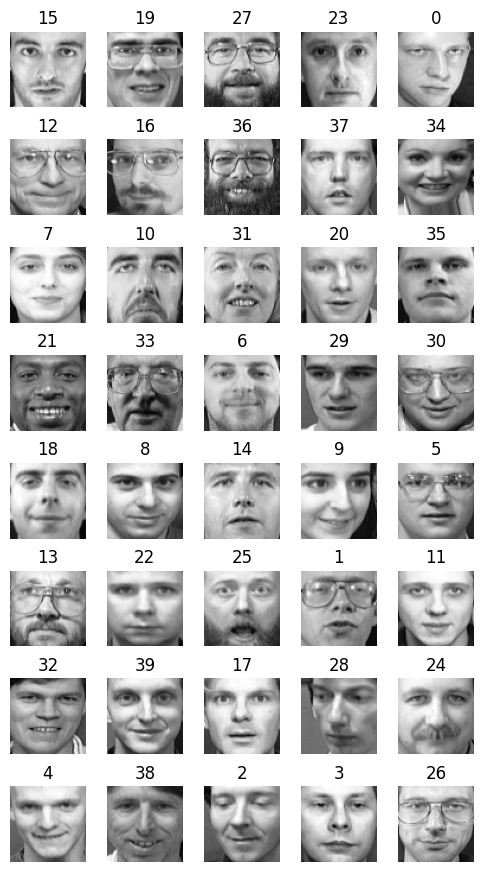

In [17]:
pintar_caras(X_valid.values, y_valid.values)


In [18]:
X_train


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4086,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095
315,0.181818,0.338843,0.355372,0.404959,0.438017,0.458678,0.471074,0.479339,0.491736,0.479339,...,0.152893,0.285124,0.392562,0.256198,0.396694,0.433884,0.392562,0.392562,0.454545,0.454545
393,0.578512,0.603306,0.632231,0.665289,0.677686,0.710744,0.723140,0.739669,0.739669,0.743802,...,0.157025,0.177686,0.194215,0.198347,0.206612,0.194215,0.165289,0.177686,0.161157,0.152893
5,0.520661,0.533058,0.541322,0.578512,0.623967,0.640496,0.648760,0.640496,0.648760,0.644628,...,0.330579,0.425620,0.450413,0.400826,0.388430,0.367769,0.309917,0.371901,0.367769,0.355372
1,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.400826,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744
283,0.289256,0.239669,0.227273,0.528926,0.772727,0.826446,0.834711,0.838843,0.842975,0.838843,...,0.280992,0.252066,0.194215,0.140496,0.165289,0.301653,0.169421,0.095041,0.107438,0.111570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,0.376033,0.359504,0.293388,0.123967,0.314050,0.582645,0.603306,0.619835,0.636364,0.644628,...,0.347107,0.363636,0.384298,0.404959,0.409091,0.417355,0.425620,0.446281,0.454545,0.462810
224,0.586777,0.702479,0.731405,0.731405,0.743802,0.772727,0.793388,0.814050,0.822314,0.847107,...,0.384298,0.520661,0.710744,0.623967,0.371901,0.400826,0.260331,0.198347,0.243802,0.256198
140,0.185950,0.342975,0.512397,0.570248,0.628099,0.615702,0.652893,0.661157,0.685950,0.727273,...,0.404959,0.351240,0.326446,0.355372,0.429752,0.487603,0.371901,0.301653,0.322314,0.318182
395,0.194215,0.223140,0.314050,0.500000,0.636364,0.735537,0.797521,0.826446,0.847107,0.847107,...,0.210744,0.206612,0.181818,0.165289,0.123967,0.123967,0.128099,0.136364,0.169421,0.165289


### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica
que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se
correspondan con las que has utilizado en el ejercicio anterior.

In [19]:
reductor_pca = PCA(n_components=0.99)

X_train_pca = reductor_pca.fit_transform(X_train)
X_valid_pca = reductor_pca.transform(X_valid)
X_test_pca = reductor_pca.transform(X_test)

reductor_pca.n_components_


np.int64(200)

In [20]:
np.cumsum(reductor_pca.explained_variance_ratio_)


array([0.242334  , 0.38291502, 0.46137628, 0.5123788 , 0.5475775 ,
       0.581026  , 0.605612  , 0.6260505 , 0.6455014 , 0.6630067 ,
       0.6783056 , 0.6923918 , 0.70495903, 0.71609455, 0.72660697,
       0.73648816, 0.7461214 , 0.7546557 , 0.76240295, 0.7697653 ,
       0.77687615, 0.7834997 , 0.789556  , 0.79527456, 0.80070454,
       0.80610335, 0.81137735, 0.81609505, 0.8207126 , 0.824906  ,
       0.82894856, 0.8328315 , 0.83656514, 0.8401164 , 0.8434851 ,
       0.8467701 , 0.84988207, 0.8529696 , 0.8559372 , 0.8587427 ,
       0.86153364, 0.86422384, 0.8667547 , 0.8691689 , 0.8715658 ,
       0.8739348 , 0.8761833 , 0.8783984 , 0.88057107, 0.88270104,
       0.8848169 , 0.88684946, 0.88878924, 0.890706  , 0.89260316,
       0.89440125, 0.89616334, 0.8978922 , 0.8995807 , 0.9012546 ,
       0.9029021 , 0.90453875, 0.90611863, 0.90765715, 0.9091914 ,
       0.91069275, 0.9121636 , 0.9135865 , 0.9150069 , 0.9163897 ,
       0.91776586, 0.9190906 , 0.9203998 , 0.92165345, 0.92287

In [21]:
columnas_pca = [f"componente_{i}" for i in range(1, reductor_pca.n_components_ + 1)]
pd.DataFrame(X_train_pca, columns=columnas_pca)


,componente_1,componente_2,componente_3,componente_4,componente_5,componente_6,componente_7,componente_8,componente_9,componente_10,...,componente_191,componente_192,componente_193,componente_194,componente_195,componente_196,componente_197,componente_198,componente_199,componente_200
0,-10.089230,-0.775731,-0.345547,0.330954,-0.183014,-1.256527,0.083928,1.616320,-1.482774,0.417646,...,0.074321,0.107009,0.017628,0.032895,0.002391,-0.052384,-0.068860,0.001232,0.017855,-0.117899
1,-2.859151,2.103872,2.899629,-0.062361,1.417627,0.525340,0.396349,1.787963,-1.538513,-1.213832,...,0.115708,0.064526,0.197119,0.150947,-0.042204,0.040150,0.024675,0.135254,0.163939,0.252180
2,0.934632,-1.216907,2.120307,1.096305,1.926708,2.834524,-0.514909,-0.425402,0.871784,1.232579,...,-0.004014,-0.067400,-0.051856,-0.015587,-0.211697,-0.131410,0.063674,-0.027133,0.035829,0.184786
3,-7.770135,-2.332068,-0.636843,1.216383,-1.905764,0.445934,-0.726987,-0.791123,0.386293,0.625620,...,-0.085447,0.084783,0.126803,-0.027442,-0.095850,0.099992,0.079072,0.033096,-0.083565,0.111054
4,2.367695,4.838783,-2.142728,-2.669456,-1.657480,-0.280360,-0.772855,-0.088102,-2.606838,-0.042991,...,-0.041847,-0.110465,0.224171,0.298922,-0.003403,-0.037283,-0.109956,0.008930,-0.063583,-0.047057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,-3.229854,-3.275335,0.012217,-0.042759,0.699504,3.001276,-1.072412,0.495842,-1.612832,-2.421972,...,-0.050069,0.019267,-0.035153,0.151973,0.196652,0.083165,-0.043895,-0.061617,-0.146631,-0.283862
276,6.273599,1.982252,-0.824711,-2.141923,-0.154575,1.265958,0.036631,1.549930,-1.421104,0.435495,...,0.035288,-0.108929,0.050109,0.033819,-0.152373,0.049593,0.028050,-0.067436,0.011756,0.025857
277,4.544502,-0.140245,-0.565789,-0.283031,-0.359178,0.972761,0.893125,-0.858423,-0.469599,0.963283,...,0.024494,0.046139,0.172655,0.176640,0.003251,0.055877,-0.033087,-0.124598,-0.108842,0.201340
278,1.775328,6.962648,0.737293,2.422355,-4.231478,-0.792731,-3.377877,-0.466550,-0.383726,-3.356666,...,-0.134414,0.060472,0.054885,-0.228915,0.179313,0.045185,0.205503,-0.058861,0.225167,-0.039338


In [22]:
ejemplo_reconstruido = reductor_pca.inverse_transform(X_train_pca[0].reshape(1, -1))
ejemplo_reconstruido.shape[1]


4096

*Hemos reducido nuestro dataset a un número de features bastante menor que las 4096
originales, ojo si intentas pintarlas directamente con `plt.imshow` verás que no se ve
nada, porque ya no son píxeles sino componentes principales.*

### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre
el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score
de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que
proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta
seleccionar, y ya están escaladas)

In [23]:
valores_k = range(5, 151, 5)
modelos_kmeans = {}

for k in valores_k:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    modelo.fit(X_train_pca)
    modelos_kmeans[k] = modelo
    print(f"k={k} ajustado")


k=5 ajustado
k=10 ajustado
k=15 ajustado
k=20 ajustado
k=25 ajustado
k=30 ajustado
k=35 ajustado
k=40 ajustado
k=45 ajustado
k=50 ajustado
k=55 ajustado
k=60 ajustado
k=65 ajustado
k=70 ajustado
k=75 ajustado
k=80 ajustado
k=85 ajustado
k=90 ajustado
k=95 ajustado
k=100 ajustado
k=105 ajustado
k=110 ajustado
k=115 ajustado
k=120 ajustado
k=125 ajustado
k=130 ajustado
k=135 ajustado
k=140 ajustado
k=145 ajustado
k=150 ajustado


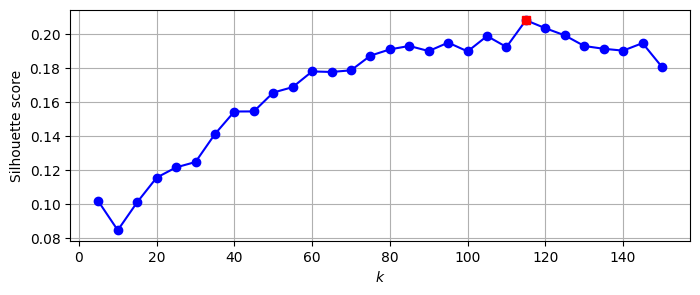

In [24]:
scores_silueta = {k: silhouette_score(X_train_pca, modelo.labels_) for k, modelo in modelos_kmeans.items()}

mejor_k = max(scores_silueta, key=scores_silueta.get)
mejor_score = scores_silueta[mejor_k]

plt.figure(figsize=(8, 3))
plt.plot(list(scores_silueta.keys()), list(scores_silueta.values()), "bo-")
plt.plot(mejor_k, mejor_score, "rs")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.grid()
plt.show()


In [25]:
mejor_k


115

### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más
concluyente o que refuerce el anterior resultado?

*El mejor número de clusters según el score de silueta suele salir bastante alto (muy
por encima de 40). Podría sorprender, ya que hay 40 personas distintas en las imágenes; sin
embargo, la misma persona puede aparecer con aspecto bastante distinto entre fotos (con o
sin gafas, ligeramente desplazada, distinta expresión...), así que K-Means tiende a preferir
más grupos, más "puros", que agrupaciones que junten todas las fotos de cada persona en un
único cluster.*

*Comprobamos si el método del codo de inercia apunta en la misma dirección:*

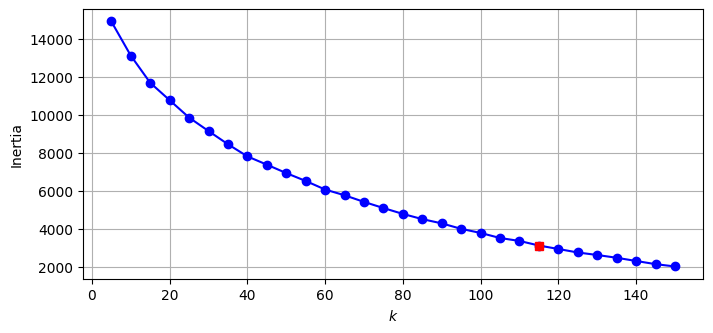

In [26]:
inercias = {k: modelo.inertia_ for k, modelo in modelos_kmeans.items()}
inercia_en_mejor_k = inercias[mejor_k]

plt.figure(figsize=(8, 3.5))
plt.plot(list(inercias.keys()), list(inercias.values()), "bo-")
plt.plot(mejor_k, inercia_en_mejor_k, "rs")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.grid()
plt.show()


*El gráfico de inercia no muestra un codo claro y evidente, así que no aporta una
conclusión tan nítida como el score de silueta -- nos quedamos con el k obtenido por ese
método.*

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a
una variable `best_model`

In [27]:
best_model = modelos_kmeans[mejor_k]
best_model


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",115
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float32](115, 200)",

### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa
que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función
que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo
tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las
features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no
verás nada. ¿Ves caras similares?

Cluster 0


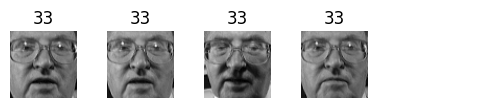

Cluster 1


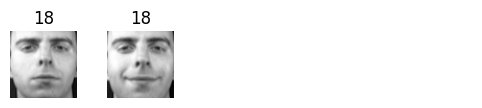

Cluster 2


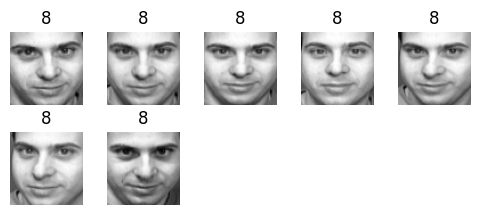

Cluster 3


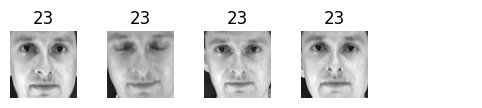

Cluster 4


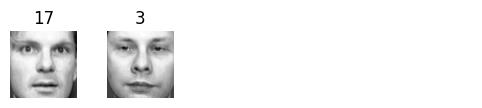

Cluster 5


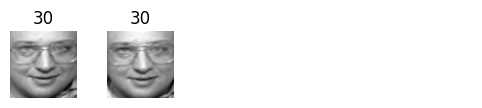

Cluster 6


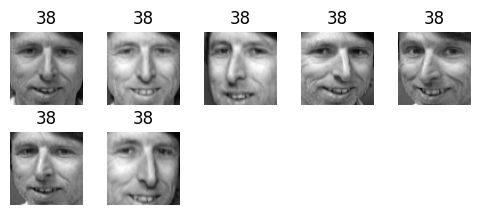

Cluster 7


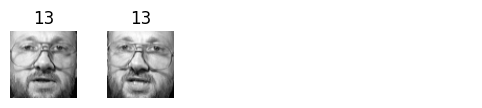

Cluster 8


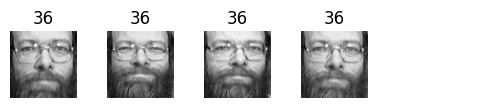

Cluster 9


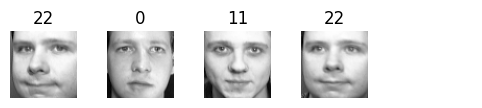

Cluster 10


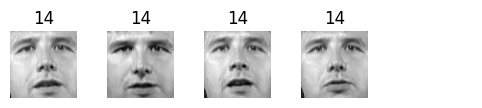

Cluster 11


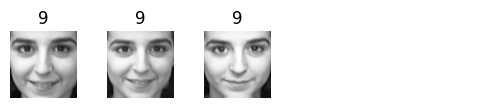

Cluster 12


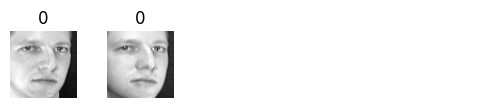

Cluster 13


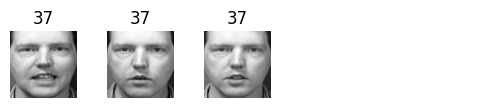

Cluster 14


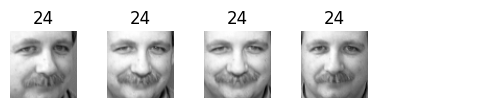

Cluster 15


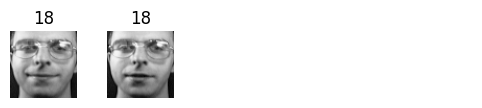

Cluster 16


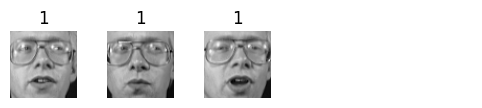

Cluster 17


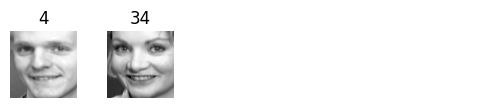

Cluster 18


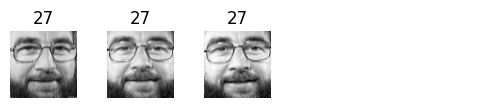

Cluster 19


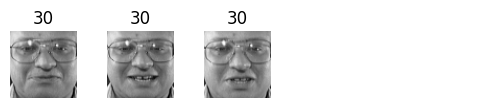

Cluster 20


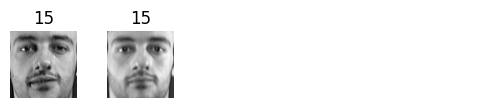

Cluster 21


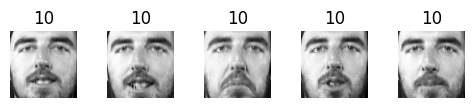

Cluster 22


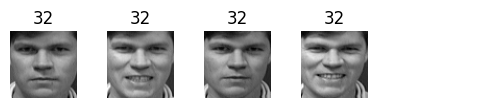

Cluster 23


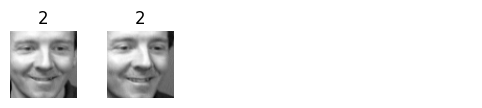

Cluster 24


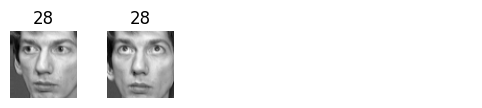

Cluster 25


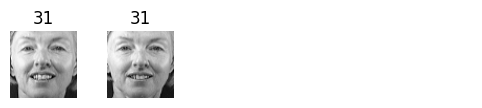

Cluster 26


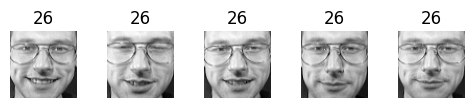

Cluster 27


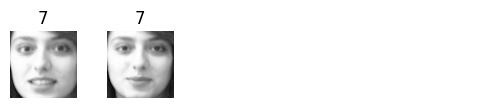

Cluster 28


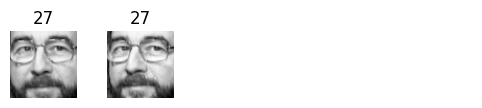

Cluster 29


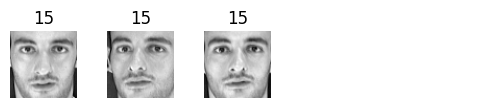

In [28]:
clusters_a_revisar = np.unique(best_model.labels_)[:30]

for id_cluster in clusters_a_revisar:
    print("Cluster", id_cluster)
    mascara = best_model.labels_ == id_cluster
    caras_del_cluster = X_train[mascara].values  # ¡ojo! las caras reales, no las componentes PCA
    etiquetas_del_cluster = y_train[mascara]
    pintar_caras(caras_del_cluster, etiquetas_del_cluster)


*Lo habitual es que en torno a dos de cada tres clusters resulten "útiles": contienen al
menos 2 imágenes, y todas pertenecen a la misma persona. El resto suelen tener algún intruso
o ser clusters con una única imagen.*

*Agrupar imágenes así puede ser demasiado impreciso como para usarlo directamente en un
modelo de clasificación (lo comprobamos más abajo), pero puede ser muy útil como ayuda para
etiquetar un dataset nuevo más rápido: revisar cluster a cluster es mucho más ágil que
revisar imagen a imagen.*

## **#2**

### #2.1

Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para
predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de
validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de
hiperparámetros déjalos a su valor por defecto)

In [29]:
len(X_train_pca)


280

In [30]:
def entrenar_y_evaluar_rf(X_tr, y_tr, X_val, y_val, n_estimadores=150, semilla=42):
    modelo_rf = RandomForestClassifier(n_estimators=n_estimadores, random_state=semilla)
    modelo_rf.fit(X_tr, y_tr)
    return modelo_rf, modelo_rf.score(X_val, y_val)


rf_pca, accuracy_pca = entrenar_y_evaluar_rf(X_train_pca, y_train, X_valid_pca, y_valid)
accuracy_pca


0.95

In [31]:
# Comparativa: ¿rinde mejor el RandomForest sobre los 4096 píxeles originales o sobre
# las componentes PCA? RandomForest ya es bastante robusto al ruido (submuestrea features en
# cada split), pero el PCA descarta el 1% de varianza residual, que en parte puede ser ruido
# de alta frecuencia. El experimento nos dice qué estrategia gana en este caso concreto.

rf_original, accuracy_original = entrenar_y_evaluar_rf(X_train, y_train, X_valid, y_valid)
accuracy_original


0.925

### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un
clasificador en el conjunto reducido. Para ello emplea el método transform de manera que
ahora las features de entrada sean las distancias de cada punto a los centroides del modelo
"best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca)
```

Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest
sobre este dataset y evalualo contra el dataset de validacion.

In [32]:
best_model


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",115
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float32](115, 200)",

In [33]:
X_train_distancias = best_model.transform(X_train_pca)
X_valid_distancias = best_model.transform(X_valid_pca)
X_test_distancias = best_model.transform(X_test_pca)


In [34]:
X_train_pca.shape


(280, 200)

In [35]:
X_train_distancias.shape


(280, 115)

In [36]:
best_model.cluster_centers_[0]


array([-8.86772346e+00,  3.13328624e-01, -4.04420090e+00, -1.14066136e+00,
        2.53570408e-01, -1.52786421e-02,  2.57888770e+00,  8.37200403e-01,
        3.89959872e-01, -1.29975581e+00, -1.89087540e-01,  9.16239977e-01,
        2.42721796e-01,  1.13115752e+00, -5.37883520e-01,  7.57282078e-01,
       -8.35108280e-01, -4.19975966e-01, -6.03433311e-01, -1.22298324e+00,
        1.00612414e+00,  2.36675471e-01, -1.21445268e-01,  1.06648600e+00,
       -4.67603534e-01, -8.08871329e-01, -2.59365588e-01, -4.66159135e-01,
       -5.63277781e-01, -5.42062104e-01,  2.73702770e-01,  5.37474811e-01,
        3.99028599e-01, -1.46116838e-01, -1.12786097e-02, -1.14221096e-01,
        3.80780786e-01, -5.07812500e-02,  4.75677371e-01,  2.40034729e-01,
        2.47817114e-01,  1.15517199e-01, -2.33413354e-01, -5.80859184e-01,
       -4.77866940e-02, -6.96415231e-02, -4.52292338e-02,  4.24088657e-01,
        1.49397969e-01,  2.87399858e-01, -2.81550229e-01,  4.84748393e-01,
       -3.95957112e-01, -

In [37]:
pd.DataFrame(X_train_distancias)


,0,1,2,3,4,5,6,7,8,9,...,105,106,107,108,109,110,111,112,113,114
0,9.501927,16.536644,13.879387,14.457418,17.116497,10.194004,7.663003,13.526636,12.617873,17.577343,...,12.183349,17.649826,12.526062,9.582863,17.377119,16.411753,14.504147,11.817189,13.892386,11.673110
1,11.516495,10.633861,8.936062,12.161423,10.860313,7.739645,10.567674,8.050632,10.486217,12.228673,...,6.904004,12.623946,7.050077,13.290885,12.727233,9.753691,8.622520,9.478168,9.835572,10.032110
2,14.276806,11.329195,3.718273,10.283859,8.889349,8.898141,12.450281,10.132376,12.022279,8.436257,...,9.135896,12.023985,9.959260,15.347828,12.941870,8.280991,10.290762,11.921394,10.248716,10.868058
3,9.002856,14.882794,11.019808,11.551350,14.736947,8.767536,5.777156,11.992103,11.208899,14.557671,...,11.634756,15.401106,11.596890,8.948182,16.122385,14.461164,13.148639,11.360086,11.666543,6.753691
4,14.666135,7.334321,11.694650,11.371653,10.054599,13.231347,14.852572,9.442581,15.083486,12.010459,...,11.537126,9.732062,10.849878,17.717066,10.315541,8.600016,11.560607,14.048731,12.927780,14.464782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,11.290565,13.088450,8.938369,10.721086,12.616589,9.294911,9.524843,11.101033,12.130177,11.843318,...,10.901301,14.526073,11.180612,12.608298,14.851533,12.389042,12.899450,10.467266,9.255983,10.211057
276,17.750498,9.651689,11.242800,12.195883,8.919407,14.609137,17.833553,11.616440,16.183590,9.793816,...,12.859104,12.409594,13.156923,20.433634,11.998267,8.655801,13.523644,15.567829,12.750637,15.580132
277,15.609393,8.477892,8.343618,8.872463,3.383172,11.553314,14.819360,9.955622,13.094547,6.394431,...,10.751457,11.006401,10.956128,17.575470,10.985103,6.448331,10.735498,13.421945,9.752254,12.413456
278,17.142109,10.027005,13.422938,12.975371,11.839313,14.590252,15.602880,11.248722,16.435720,13.888827,...,11.937366,12.285453,12.077027,18.766258,12.955399,11.138369,10.669388,15.162008,15.316821,14.763242


In [38]:
rf_distancias, accuracy_distancias = entrenar_y_evaluar_rf(
    X_train_distancias, y_train, X_valid_distancias, y_valid
)
accuracy_distancias


0.8

*No siempre ayuda reducir la dimensionalidad de esta forma -- en algunos casos puede
incluso no ser el enfoque más apropiado.*

### #2.3 EXTRA VOLUNTARIO

Busca el número de clusters k que generen un algoritmo kmeans que a su vez sus
distancias a los centroides sean las features de un clasificador RandomForest y que permita
al clasificador obtener el mejor rendimiento: ¿Qué rendimiento puedes alcanzar? (en terminos
de Accuracy)

Podríamos usar un `GridSearchCV` cambiando el dataset de features pero para ello
necesitamos un poco más de conocimiento de las tripas de sklearn. Como ya tenemos un
conjunto de validación, no necesitamos validación cruzada K-fold, y solo estamos explorando
un hiperparámetro, por lo que es más sencillo ejecutar un bucle manualmente:

In [39]:
resultados_manual = []

for k in valores_k:
    modelo_k = KMeans(n_clusters=k, n_init=10, random_state=42)
    modelo_k.fit(X_train_pca)  # KMeans no recibe y: es no supervisado

    dist_train = modelo_k.transform(X_train_pca)
    dist_valid = modelo_k.transform(X_valid_pca)

    _, accuracy_k = entrenar_y_evaluar_rf(dist_train, y_train, dist_valid, y_valid)
    resultados_manual.append({"k": k, "accuracy_valid": accuracy_k})

pd.DataFrame(resultados_manual).sort_values("accuracy_valid", ascending=False)


,k,accuracy_valid
24,125,0.900
28,145,0.850
19,100,0.850
29,150,0.850
20,105,0.850
26,135,0.850
18,95,0.825
21,110,0.825
9,50,0.825
25,130,0.825


O de forma más elegante, construir un pipeline y ejecutarlo dentro de un bucle
manualmente.

In [40]:
resultados_pipeline = []

for k in valores_k:
    pipeline = make_pipeline(
        KMeans(n_clusters=k, n_init=10, random_state=42),
        RandomForestClassifier(n_estimators=150, random_state=42),
    )
    pipeline.fit(X_train_pca, y_train)
    resultados_pipeline.append({"k": k, "accuracy_valid": pipeline.score(X_valid_pca, y_valid)})

pd.DataFrame(resultados_pipeline).sort_values("accuracy_valid", ascending=False)


,k,accuracy_valid
24,125,0.900
28,145,0.850
19,100,0.850
29,150,0.850
20,105,0.850
26,135,0.850
18,95,0.825
21,110,0.825
9,50,0.825
25,130,0.825


*No suele obtenerse una gran mejora sobre el RandomForest entrenado directamente sobre
las componentes PCA -- con solo 40 muestras de validación, cada acierto/fallo mueve la
accuracy en saltos de 0.025, así que hay que interpretar las diferencias pequeñas con
cautela. Aun así, este experimento nos ha servido para practicar clustering y para explorar
K-Means como técnica de reducción de dimensionalidad (aquí con poco éxito frente al PCA ya
aplicado).*